In [1]:
import numpy as np
import h5py
from time import time
import matplotlib.pyplot as plt
from scipy.ndimage import shift
from scipy.ndimage import gaussian_filter
from scipy.ndimage import zoom
import imageio
from PIL import Image
from skimage.registration import phase_cross_correlation
import matplotlib.animation as animation
import pylab as pl
from IPython import display
import time
from scipy.stats import poisson


# Generating the data
### 1. Reading the image

In [2]:
img1 = Image.open('CFEL.jpg')
img1 =  img1.convert("L")

# Resize the image
img1 = img1.resize((256, 256))
img1 = np.array(img1)
img1 = img1/img1.max()

f = img1

(-0.5, 255.5, 255.5, -0.5)

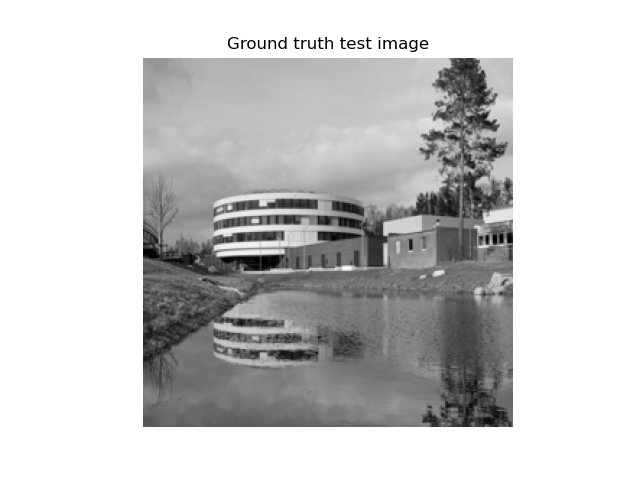

In [3]:
%matplotlib ipympl

plt.figure()
plt.imshow(f, cmap='gray')
plt.title('Ground truth test image')
plt.axis('off')

## 2. Generating Ptychographic data; exit field (small ROIs), the corresponding diffraction patterns, and saving probe positions

In [4]:
# Generating exit field (small ROIs), the corresponding diffraction patterns, and saving probe positions
N = f.shape[0]
Np = N/2 
grid_p = np.arange(-Np, Np,1)
x, y = np.meshgrid(grid_p, grid_p)
x = x - x.min()
y = y - y.min()

ROI = 128
grid_probe = np.arange(-ROI//2, ROI//2, 1)
x1, y1 = np.meshgrid(grid_probe, grid_probe)
Probe_support = (np.sqrt(x1**2 + y1**2)<=64) #Circular Probe
#Probe_support = np.ones((128, 128))#(np.abs(x1)<=55)*(np.abs(y1)<=55)

def select_ROI(centre, ObjForRoi):
    x_start = max(centre[0] - ROI // 2, 0)
    y_start = max(centre[1] - ROI // 2, 0)
    x_end = min(x_start + ROI, N)
    y_end = min(y_start + ROI, N)
    Object_ROI = ObjForRoi[y_start:y_end, x_start:x_end] #size (104, 104)
    return Object_ROI
    
    

Object = f
N_shift = 25
exit = np.zeros((N_shift, ROI, ROI))
mod02 = np.zeros((N_shift, ROI, ROI))
iter_num = 0

probe_position = []

N_photons = 10**4 #Number of Photons


for num_y in range(5):
    for num_x in range(5):
        # For 5X5 position scans
        x0 = 64 + 32*(num_x)
        y0 = 64 + 32*(num_y)
        # For 4X4 position scans, change N_shift to 16
        #x0 = 52 + 52*(num_x)
        #y0 = 52 + 52*(num_y)
        centre = (x0, y0)
        probe_position.append(centre)
        Object_j = select_ROI(centre, Object)
        exit_j = Object_j * Probe_support  #size(104, 104)
        exit[iter_num] = exit_j
        Exit_FT = np.fft.fftshift( np.fft.fft2(np.fft.ifftshift(exit[iter_num])))
        mod02[iter_num] = np.abs(Exit_FT)
        
        ## If assume Poisson Noise 
        # I_n = np.abs(Exit_FT)**2
        # In_mean = np.mean(I_n)
        # scaled_I = N_photons*I_n/In_mean
        # poisson_random = poisson.rvs(scaled_I)
        # mod0 = (poisson_random / N_photons)*In_mean
        # mod02[iter_num] = np.sqrt(mod0)
        
        iter_num = iter_num +1




(25, 128, 128)


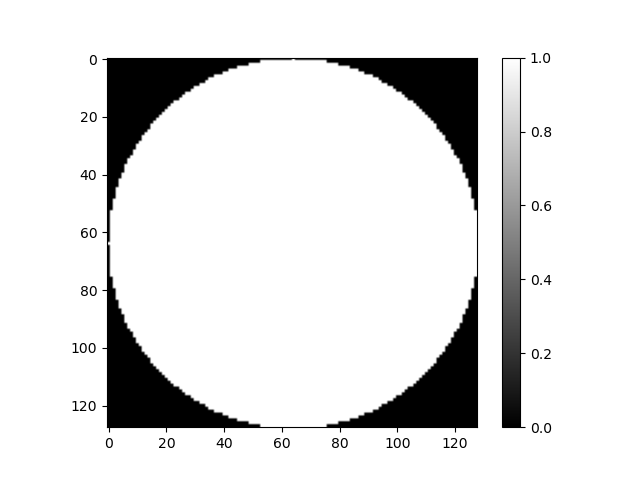

In [5]:

print(mod02.shape)
%matplotlib ipympl

plt.figure()
#plt.imshow(mod02[0]**0.25, cmap ='gray')
plt.imshow(Probe_support, cmap ='gray')

plt.colorbar()

## Displaying all small FOVs

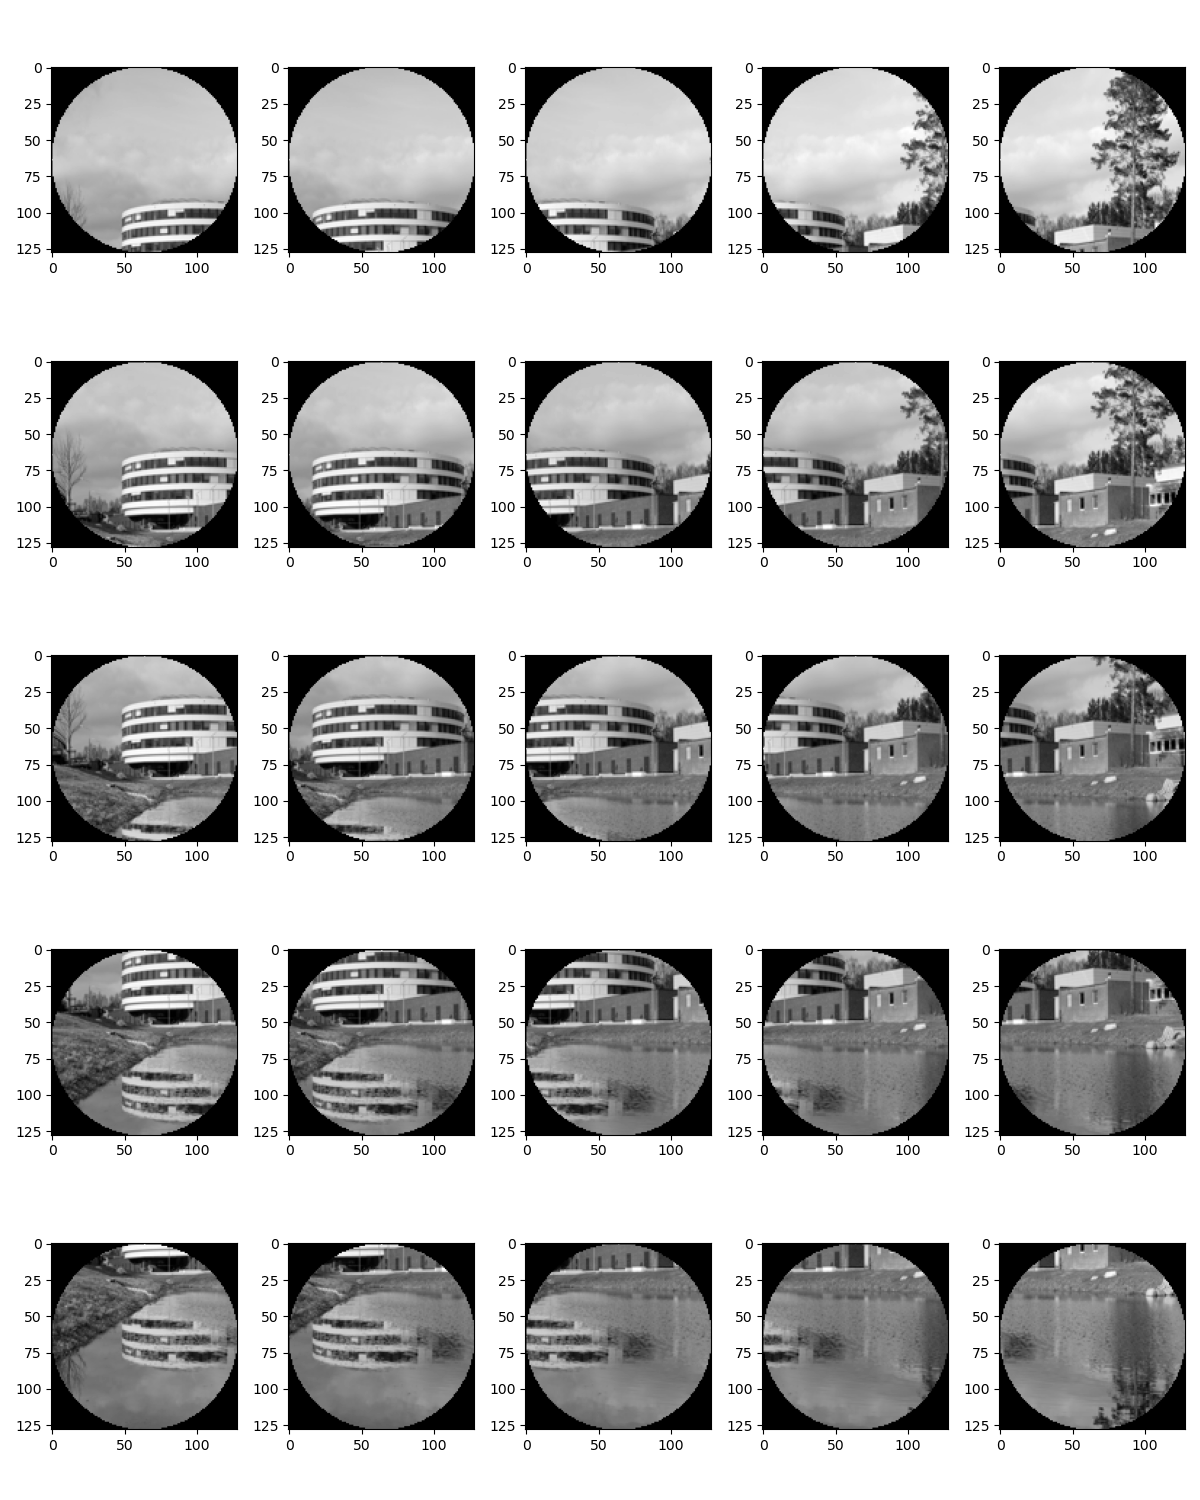

In [6]:


num_images = exit.shape[0]
grid_size = int(np.ceil(np.sqrt(num_images)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 15))
axes = axes.flatten()

for i in range(num_images):
    #axes[i].imshow(np.abs(mod02[i])**0.25, cmap='gray')  
    axes[i].imshow(exit[i], cmap='gray')  
    #axes[i].title(f'probe position {i+1}')
#axes[i].axis('off')  

# Hide any remaining subplots if the grid is larger than the number of images
for i in range(num_images, grid_size * grid_size):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Image Reconstruction

In [7]:
# Image Reconstruction using ePIE
def get_cord(centre):
    x_start = max(centre[0] - ROI // 2, 0)
    y_start = max(centre[1] - ROI // 2, 0)
    x_end = min(x_start + ROI, N)
    y_end = min(y_start + ROI, N)
    return x_start, y_start, x_end, y_end

#Starting guess for Object
phi_0 = np.random.random((N, N))
Object = np.random.random((N, N))*np.exp(1j*0.02*phi_0)

#Saving the reconstructed Object and Probe 
Object_recovery_frames =[]
Probe_rec_frames =[]

Probe_est = np.random.random((ROI, ROI))*Probe_support # Shape (104, 104)
ProbeS_all = np.zeros((N,N))

max_iter = 100

# %matplotlib ipympl
for iter_num in range(max_iter):
    Object_est = Object.copy()
    Object_recovery_frames.append(Object)
    Probe_rec_frames.append(Probe_est)
    for k in range(N_shift):
        probe_centre = probe_position[k]
        cl, rl, ch, rh = get_cord(probe_centre)
        Object_nk = Object[rl:rh, cl:ch]
        psi_nk = Object_nk*Probe_est
        PSI_nk = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(psi_nk)))
        
        ##FOR NOISY DATA
        #mask = (mod02[k]==0)
        
        PSI_PM = mod02[k]*np.exp(1j*np.angle(PSI_nk))
        psi_PM  =  np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(PSI_PM)))*Probe_support
        delta_psi = psi_PM - psi_nk
        
        #OBJECT UPDATE STEP 
        prev_object =  Object_nk.copy()# (104, 104) Object shape
        modP = np.abs(Probe_est)
        w = np.conjugate(Probe_est)/((modP).max()+1e-23)
        d_obj = w*delta_psi
        Object_n = prev_object + d_obj
        
        Object[rl:rh, cl:ch] = (Object_n) #+ ( (1-Probe_support)*(Object[rl:rh, cl:ch]) )
        Object_updated_ROI = Object[rl:rh, cl:ch]
        
        #Probe Update
        modObject = np.abs(Object_updated_ROI)
        w_obj = np.conjugate(Object_updated_ROI)/((modObject).max()+ 1e-23)
        d_probe = w_obj*delta_psi
        Probe_update = (Probe_est + d_probe)*Probe_support
        ProbeS_all[rl:rh, cl:ch] = Probe_update + (1-Probe_support)*ProbeS_all[rl:rh, cl:ch]
        Probe_est = np.abs(Probe_update).copy()
     

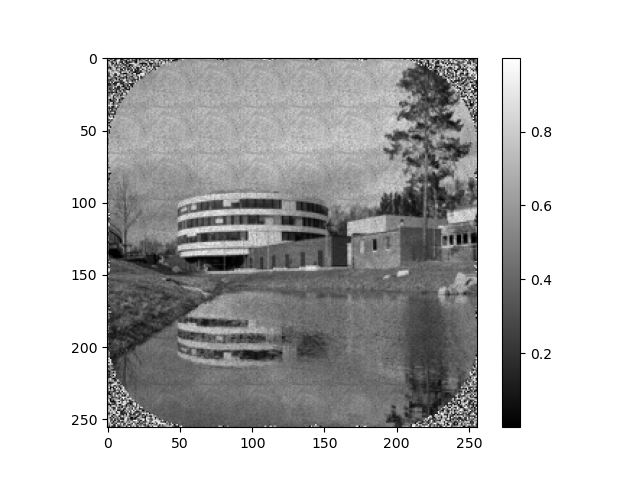

In [8]:
%matplotlib ipympl

plt.figure()
plt.imshow(np.abs(Object), cmap = 'gray')
plt.colorbar()


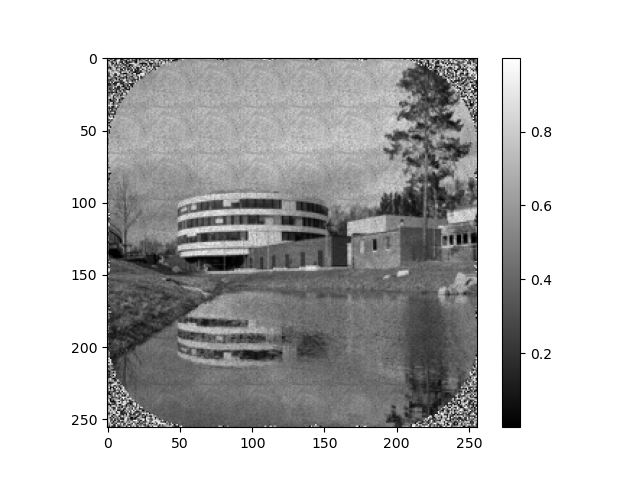

In [9]:
%matplotlib ipympl

plt.figure()
plt.imshow(np.abs(Object), cmap = 'gray')
plt.colorbar()


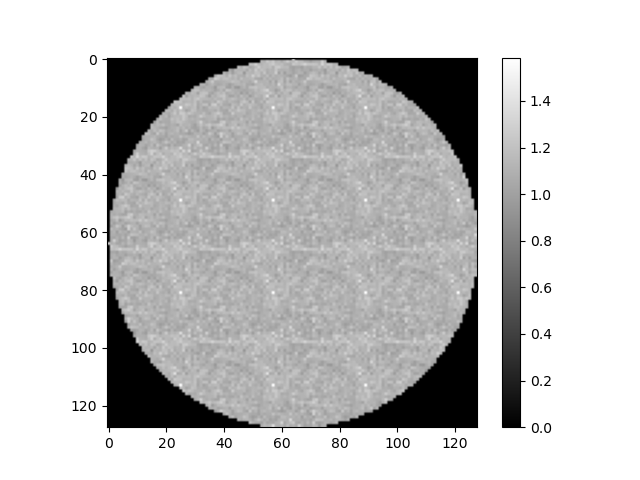

In [10]:
%matplotlib ipympl
a = ProbeS_all[rl:rh, cl:ch]

plt.figure()
plt.imshow(Probe_est, cmap = 'gray')
plt.colorbar()

In [ ]:
#Code for Animation

# frames = np.array(np.abs(Object_recovery_frames))
# %matplotlib ipympl
# fig = plt.figure(figsize=(8,6))
# i=0
# N_frames = frames.shape[0]
# im = plt.imshow(frames[0],animated=True, cmap='gray')
# plt.title(f'iter {i+1}')
# plt.colorbar()

# def updatefig(*args):
#     global i
#     if ((i<N_frames)):
#         i += 1
#     else:
#         i=0
#     plt.title(f'iter{i+1}')
#     im.set_array(frames[i])
#     return im,
# ani = animation.FuncAnimation(fig, updatefig,  blit=True, frames=range(0,N_frames))

# ani.save(f'imrec.gif', writer=animation.PillowWriter(fps=1))
# plt.show()

In [10]:
N

256